# Modelo de Redes neuronales simple (fully-connected)

Este notebook carga los datos ya preprocesados en `preprocesamiento.ipynb` (submuestra de 600 imágenes/clase, 64x64, splits train/val/test) y entrena una red fully-connected como baseline para comparar contra las CNNs.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

from pathlib import Path
import keras
from keras import layers, models
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

keras.utils.set_random_seed(43) 

DATA_PATH = Path("asl-alphabet/processed/asl_64x64_600pc.npz")
assert DATA_PATH.exists(), f"No se encontró {DATA_PATH}. Corre primero preprocesamiento.ipynb"


data = np.load(DATA_PATH, allow_pickle=True)

X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]
class_names = data["class_names"]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Clases:", list(class_names))
print("Dtype de X:", X_train.dtype, "— rango:", X_train.min(), "-", X_train.max())

Train: (12180, 64, 64, 3) (12180,)
Val:   (2610, 64, 64, 3) (2610,)
Test:  (2610, 64, 64, 3) (2610,)
Clases: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z'), np.str_('del'), np.str_('nothing'), np.str_('space')]
Dtype de X: uint8 — rango: 0 - 255


### Normalizar los datos

In [2]:
X_train_flat = X_train.astype(np.float32).reshape(len(X_train), -1) / 255.0
X_val_flat   = X_val.astype(np.float32).reshape(len(X_val), -1) / 255.0
X_test_flat  = X_test.astype(np.float32).reshape(len(X_test), -1) / 255.0

print(X_train_flat.shape, X_val_flat.shape, X_test_flat.shape)
n_classes = len(class_names)


(12180, 12288) (2610, 12288) (2610, 12288)


Se normalizan los datos que vienen en uint8 (0-255) a que sean (0-1) y se aplanan a (N, 12288)

### Construir modelo

In [3]:
model_fc = models.Sequential([
    layers.Input(shape=(64*64*3,)),
    layers.Dense(512, activation="relu", kernel_initializer="he_normal"),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu", kernel_initializer="he_normal"),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation="softmax"),
])

model_fc.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_fc.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,361,373 (24.27 MB)

 Trainable params: 6,361,373 (24.27 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
early_stop = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)

history = model_fc.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
)

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.0379 - loss: 3.5056 - val_accuracy: 0.0540 - val_loss: 3.3440
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.0392 - loss: 3.3351 - val_accuracy: 0.0659 - val_loss: 3.2439
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.0491 - loss: 3.2785 - val_accuracy: 0.0774 - val_loss: 3.1931
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.0559 - loss: 3.2432 - val_accuracy: 0.0851 - val_loss: 3.1059
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.0557 - loss: 3.2209 - val_accuracy: 0.0897 - val_loss: 3.1082
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.0589 - loss: 3.1992 - val_accuracy: 0.1008 - val_loss: 3.1215
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.0589 - loss: 3.1805 - val_accuracy: 0.0973 - val_loss: 3.0270
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.0604 - loss: 3.1736 - val_

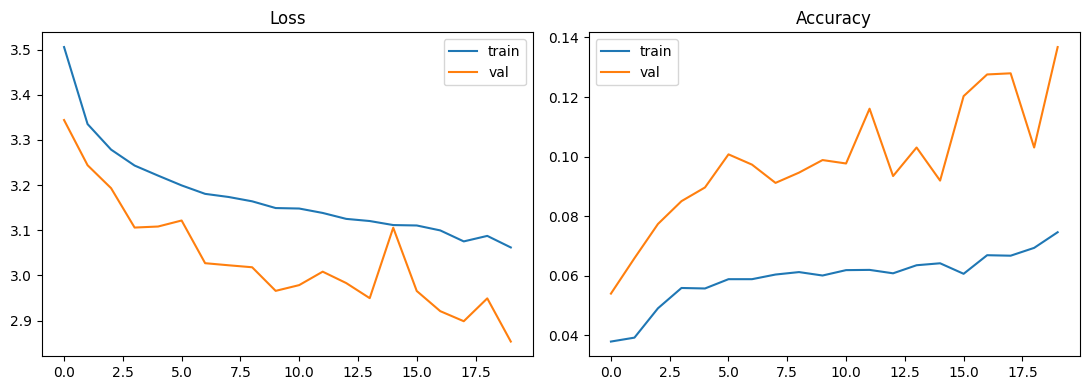

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.show()

In [6]:
test_loss, test_acc = model_fc.evaluate(X_test_flat, y_test)
print(f"Test accuracy (FC): {test_acc:.4f}")

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1169 - loss: 2.8481
Test accuracy (FC): 0.1169


### Matriz de confusion y reporte por clase


 1/82 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        90
           B       0.00      0.00      0.00        90
           C       0.10      0.46      0.16        90
           D       0.00      0.00      0.00        90
           E       0.21      0.24      0.22        90
           F       0.00      0.00      0.00        90
           G       0.05      0.06      0.05        90
           H       0.00      0.00      0.00        90
           I       0.00      0.00      0.00        90
           J       0.06      0.61      0.11        90
           K       0.00      0.00      0.00        90
           L       0.34      0.14      0.20        90
           M       0.21      0.17      0.18        90
           N       0.32      0.24      0.28        90
           O       0.22      0.19      0.20        90
           P       0.25      0.43      0.32        90
           Q       0.29      0.04      0.0

c:\Users\sofia\OneDrive\Documentos\UVG\6to semestre\Mineria de datos\Lab2-Mineria\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sofia\OneDrive\Documentos\UVG\6to semestre\Mineria de datos\Lab2-Mineria\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sofia\OneDrive\Documentos\UVG\6to semestre\Mineria de datos\Lab2-Mineria\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

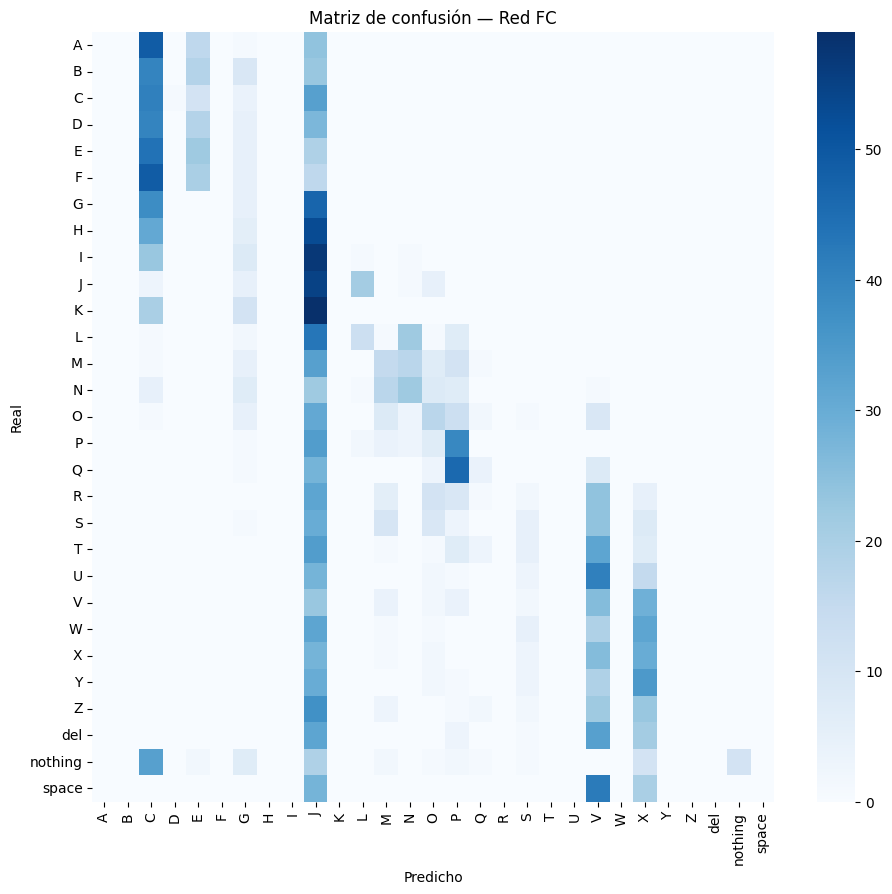

In [7]:
y_pred = model_fc.predict(X_test_flat).argmax(axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(11, 10))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.title("Matriz de confusión — Red FC")
plt.show()

## Guardar modelo para comparaciones

In [8]:
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

model_fc.save(MODELS_DIR / "FC_simple.keras")
print("Modelo guardado en", (MODELS_DIR / "FC_simple.keras").resolve())

Modelo guardado en C:\Users\sofia\Documents\DataScience\Lab3-DataScience\models\FC_simple.keras
